Model Performance Comparison


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9990,1.0000,0.9706,0.9851
3,KNN,0.9990,1.0000,0.9706,0.9851
2,Random Forest,0.9975,1.0000,0.9265,0.9618
1,Decision Tree,0.9970,0.9429,0.9706,0.9565


Best Model: Logistic Regression
Best model saved successfully


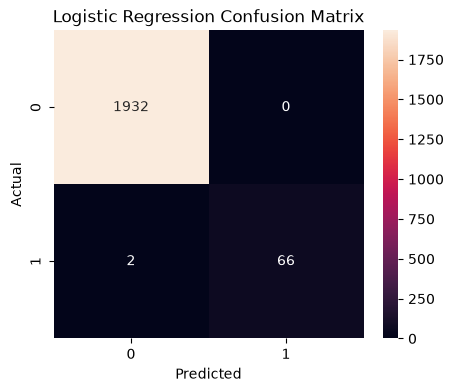

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.97      0.99        68

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


# Load dataset
df = pd.read_csv("../02_Data/Raw/ai4i2020.csv")


# Remove unnecessary columns
df.drop(columns=["UDI", "Product ID"], inplace=True)


# Encode categorical feature
encoder = LabelEncoder()
df["Type"] = encoder.fit_transform(df["Type"])


# Feature Engineering

df["Temperature Difference"] = (
    df["Process temperature [K]"] -
    df["Air temperature [K]"]
)


df["Tool Wear Level"] = pd.cut(
    df["Tool wear [min]"],
    bins=[0, 100, 200, df["Tool wear [min]"].max()],
    labels=[0, 1, 2],
    include_lowest=True
)


df["Tool Wear Level"] = df["Tool Wear Level"].astype(int)


# Separate features and target

X = df.drop("Machine failure", axis=1)
y = df["Machine failure"]


# Train test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# Feature scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Define models

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ),

    "KNN": KNeighborsClassifier()

}


results = []
model_predictions = {}
trained_models = {}


# Train and compare models

for name, model in models.items():

    if name in ["Logistic Regression", "KNN"]:

        model.fit(X_train_scaled, y_train)
        predictions = model.predict(X_test_scaled)

    else:

        model.fit(X_train, y_train)
        predictions = model.predict(X_test)


    model_predictions[name] = predictions
    trained_models[name] = model


    results.append({

        "Model": name,

        "Accuracy": round(
            accuracy_score(y_test, predictions),
            4
        ),

        "Precision": round(
            precision_score(y_test, predictions),
            4
        ),

        "Recall": round(
            recall_score(y_test, predictions),
            4
        ),

        "F1 Score": round(
            f1_score(y_test, predictions),
            4
        )

    })


# Model comparison

comparison_df = pd.DataFrame(results)


print("Model Performance Comparison")

display(
    comparison_df.sort_values(
        by="F1 Score",
        ascending=False
    )
)


# Select best model

best_model = comparison_df.sort_values(
    by="F1 Score",
    ascending=False
).iloc[0]["Model"]


print("Best Model:", best_model)


# Save best model

final_model = trained_models[best_model]

joblib.dump(
    final_model,
    "../04_Models/best_model.pkl" 
)

print("Best model saved successfully")


# Confusion Matrix

cm = confusion_matrix(
    y_test,
    model_predictions[best_model]
)


plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title(f"{best_model} Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "../06_Images/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# Classification Report

print(
    classification_report(
        y_test,
        model_predictions[best_model]
    )
)

# Industrial Equipment Reliability Intelligence Platform

## Model Comparison

This notebook compares the performance of trained machine learning models using evaluation metrics and confusion matrices to identify the most suitable model for machine failure prediction.